In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [20]:
ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)

ratings.head()
movies.head()

Ratings shape: (105339, 4)
Movies shape: (10329, 3)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [21]:
# Filter popular movies (>50 ratings)
movie_counts = ratings['movieId'].value_counts()
popular_movies_ids = movie_counts[movie_counts > 50].index

ratings = ratings[ratings['movieId'].isin(popular_movies_ids)]

# Filter active users (>50 ratings)
user_counts = ratings['userId'].value_counts()
active_users = user_counts[user_counts > 50].index

ratings = ratings[ratings['userId'].isin(active_users)]

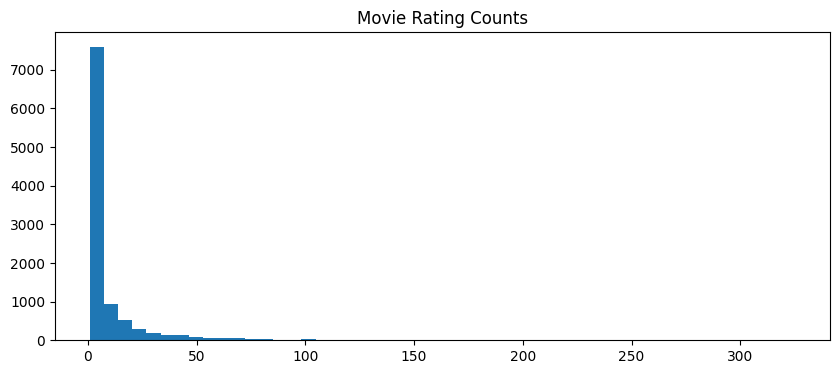

In [22]:
plt.figure(figsize=(10,4))
plt.hist(movie_counts, bins=50)
plt.title("Movie Rating Counts")
plt.show()

In [23]:
data = ratings.merge(movies, on='movieId')
data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,16,4.0,1217897793,Casino (1995),Crime|Drama
1,1,32,4.0,1217896246,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller
2,1,47,4.0,1217896556,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
3,1,50,4.0,1217896523,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
4,1,110,4.0,1217896150,Braveheart (1995),Action|Drama|War


In [24]:
movie_stats = data.groupby('title').agg({
    'rating': ['mean', 'count']
})

movie_stats.columns = ['avg_rating', 'num_ratings']

popular_movies = movie_stats.sort_values(
    ['avg_rating', 'num_ratings'], ascending=False
)

popular_movies = popular_movies[popular_movies['num_ratings'] > 50]

popular_movies.head(10)

,avg_rating,num_ratings
title,,
"Shawshank Redemption, The (1994)",4.468750,176
Rear Window (1954),4.394737,57
Chinatown (1974),4.326923,52
Citizen Kane (1941),4.319672,61
"Godfather, The (1972)",4.306569,137
"Usual Suspects, The (1995)",4.292994,157
One Flew Over the Cuckoo's Nest (1975),4.286364,110
Goodfellas (1990),4.276190,105
Inception (2010),4.269231,52


In [25]:
user_item = data.pivot_table(
    index='userId',
    columns='title',
    values='rating'
).fillna(0)

In [26]:
user_item_sparse = csr_matrix(user_item.values)

user_similarity = cosine_similarity(user_item_sparse)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item.index,
    columns=user_item.index
)

In [27]:
def recommend_movies(user_id, n=5):

    # Cold start
    if user_id not in user_item.index:
        return popular_movies.head(n).index.tolist()

    # Similar users
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:11]
    similar_ratings = user_item.loc[similar_users.index]
    sim_scores = user_similarity_df[user_id].loc[similar_users.index]

    # Weighted average
    weighted_scores = (similar_ratings.T * sim_scores).T.sum() / sim_scores.sum()
    weighted_scores = weighted_scores.sort_values(ascending=False)

    # Remove watched
    user_watched = user_item.loc[user_id]
    weighted_scores = weighted_scores[user_watched == 0]

    return weighted_scores.head(n).index.tolist()

recommend_movies(1)

['Dark Knight, The (2008)',
 'Memento (2000)',
 'Eternal Sunshine of the Spotless Mind (2004)',
 'Léon: The Professional (a.k.a. The Professional) (Léon) (1994)',
 'Kill Bill: Vol. 2 (2004)']

In [28]:
# IMPORTANT FIX
movies = movies.reset_index(drop=True)

movies['genres'] = movies['genres'].fillna('')

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['genres'])

content_similarity = cosine_similarity(tfidf_matrix)

indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

In [29]:
def recommend_content(title, n=5):

    if title not in indices:
        return ["Movie not found"]

    idx = indices[title]

    if idx >= len(content_similarity):
        return ["Index error"]

    sim_scores = list(enumerate(content_similarity[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:n+1]

    movie_indices = [i[0] for i in sim_scores]

    return movies['title'].iloc[movie_indices].tolist()

recommend_content("Toy Story (1995)")

['Antz (1998)',
 'Toy Story 2 (1999)',
 'Adventures of Rocky and Bullwinkle, The (2000)',
 "Emperor's New Groove, The (2000)",
 'Monsters, Inc. (2001)']

In [30]:
def hybrid_recommend(user_id, title, n=5):
    return list(dict.fromkeys(
        recommend_movies(user_id, 10) + recommend_content(title, 10)
    ))[:n]

hybrid_recommend(1, "Toy Story (1995)")

['Dark Knight, The (2008)',
 'Memento (2000)',
 'Eternal Sunshine of the Spotless Mind (2004)',
 'Léon: The Professional (a.k.a. The Professional) (Léon) (1994)',
 'Kill Bill: Vol. 2 (2004)']

In [31]:
movie_user = data.pivot_table(
    index='title',
    columns='userId',
    values='rating'
).fillna(0)

movie_user_sparse = csr_matrix(movie_user.values)

knn_model = NearestNeighbors(metric='cosine', algorithm='brute')
knn_model.fit(movie_user_sparse)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [32]:
def recommend_knn(movie_name, n=5):

    if movie_name not in movie_user.index:
        return ["Movie not found"]

    idx = movie_user.index.get_loc(movie_name)

    distances, indices_knn = knn_model.kneighbors(
        movie_user_sparse[idx], n_neighbors=n+1
    )

    return [movie_user.index[i] for i in indices_knn.flatten()[1:]]

recommend_knn("Toy Story (1995)")

['Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981)',
 'Star Wars: Episode VI - Return of the Jedi (1983)',
 'Star Wars: Episode IV - A New Hope (1977)',
 'Star Wars: Episode V - The Empire Strikes Back (1980)',
 'Princess Bride, The (1987)']

In [33]:
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

In [34]:
train_user_item = train_data.pivot_table(
    index='userId',
    columns='title',
    values='rating'
).fillna(0)

train_similarity = cosine_similarity(train_user_item)

train_similarity_df = pd.DataFrame(
    train_similarity,
    index=train_user_item.index,
    columns=train_user_item.index
)

In [35]:
def get_actual(user_id):
    return test_data[
        (test_data['userId'] == user_id) &
        (test_data['rating'] >= 4)
    ]['title'].tolist()

In [36]:
def recommend_train(user_id, n=5):

    if user_id not in train_user_item.index:
        return data.groupby('title')['rating'].mean().sort_values(ascending=False).head(n).index.tolist()

    similar_users = train_similarity_df[user_id].sort_values(ascending=False)[1:11]
    similar_ratings = train_user_item.loc[similar_users.index]
    sim_scores = train_similarity_df[user_id].loc[similar_users.index]

    weighted_scores = (similar_ratings.T * sim_scores).T.sum() / sim_scores.sum()
    weighted_scores = weighted_scores.sort_values(ascending=False)

    user_watched = train_user_item.loc[user_id]
    weighted_scores = weighted_scores[user_watched == 0]

    return weighted_scores.head(n).index.tolist()

In [37]:
def precision_at_k(user_id, k=5):

    recommended = recommend_train(user_id, k)
    if not recommended:
        return 0

    actual = get_actual(user_id)
    if not actual:
        return 0

    return len(set(recommended) & set(actual)) / k


def recall_at_k(user_id, k=5):

    actual = get_actual(user_id)
    if not actual:
        return 0

    recommended = recommend_train(user_id, k)

    return len(set(recommended) & set(actual)) / len(actual)

In [38]:
users = test_data['userId'].unique()[:50]

precision_scores = []
recall_scores = []

for user in users:
    precision_scores.append(precision_at_k(user))
    recall_scores.append(recall_at_k(user))

print("🔥 FINAL RESULTS")
print("Precision@5:", np.mean(precision_scores))
print("Recall@5:", np.mean(recall_scores))

🔥 FINAL RESULTS
Precision@5: 0.37199999999999994
Recall@5: 0.14099843691730102
